In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
import sqlalchemy as sal
engine = sal.create_engine('mssql+pyodbc://LAPTOP-MLTUFQ26/master?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')
conn=engine.connect()

C:\Users\Krish Khandelwal\AppData\Local\Temp\ipykernel_16020\1643680056.py:3: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  conn=engine.connect()


In [5]:
df.to_sql('netflix_raw', con=conn , index=False, if_exists = 'append')

107

In [6]:
conn.close()

In [4]:
df[df.show_id=='s2640']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2639,s2640,TV Show,دفعة القاهرة,NaN,"Bashar al-Shatti, Fatima Al Safi, Maram Baloch...",NaN,"April 25, 2020",2019,TV-14,1 Season,"International TV Shows, TV Dramas",A group of women leaves Kuwait to attend unive...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### Movies vs TV Shows Distribution

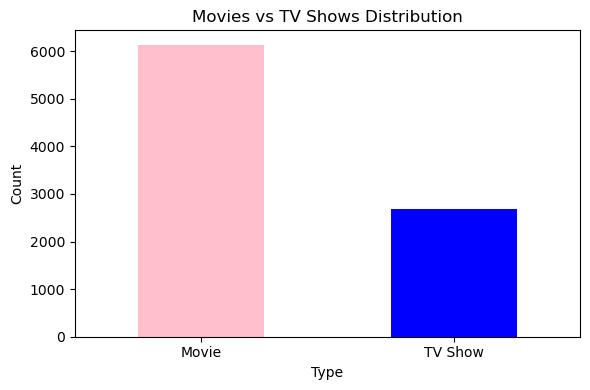

In [7]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind='bar', color=['pink','blue'])
plt.title('Movies vs TV Shows Distribution', fontsize=12)
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()





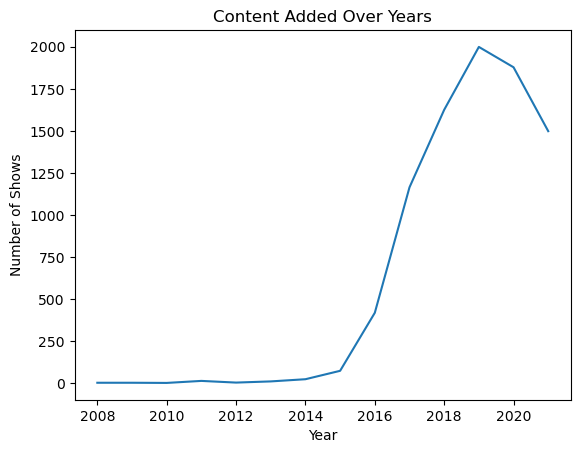

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

year_counts = df['year_added'].value_counts().sort_index()

plt.figure()
year_counts.plot(kind='line')
plt.title('Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.show()

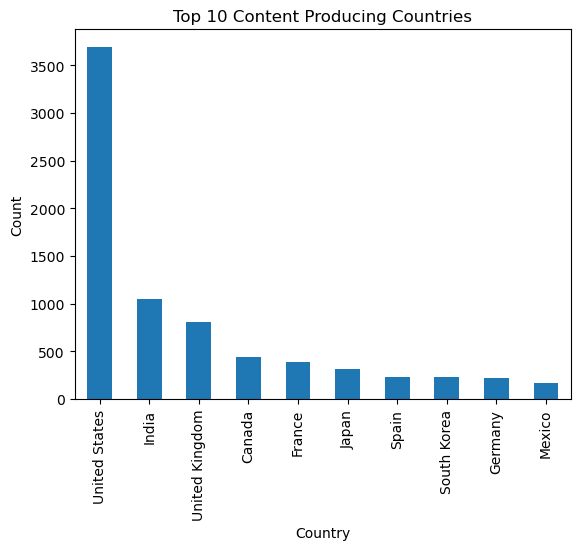

In [12]:

country_counts = (
    df['country']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()   # removes extra spaces
    .value_counts()
    .head(10)
)
plt.figure()
country_counts.plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

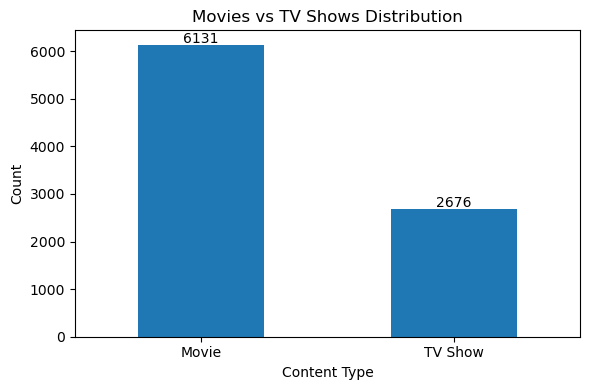

In [13]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows Distribution', fontsize=12)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)

for i, v in enumerate(type_counts):
    plt.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# for each director count the no of movies and tv shows created by them in separate columns for directors who have created tv shows and movies both 